# ENOE 2026 T1 — Análisis para un modelo de estimación de ingresos

Continuación del notebook de unión. Entrada: `salida_enoe/enoe_2026_1t_unificado.parquet`
(406,740 filas × 523 columnas).

## Qué pregunta responde cada sección

| § | Pregunta | Por qué importa para el modelo |
|---|---|---|
| 1 | ¿Cómo se distribuye realmente `ingocup`? | Define la transformación y la función de pérdida |
| 2 | ¿Qué son los ceros? | **Sección crítica.** `ingocup = 0` mezcla tres cosas distintas |
| 3 | ¿La no respuesta es MAR o MNAR? | `c2_p6c` permite *observar* el ingreso de quien no dio monto |
| 4 | ¿Cuánta señal aporta cada bloque de variables? | Fija el techo de un modelo sin datos laborales |
| 5 | ¿Cuánto explica la geografía? | Justifica o descarta el enriquecimiento geográfico |
| 6 | ¿Cómo es el segmento informal? | Es el proxy más cercano a tu población no-hit |
| 7 | Tablas de calibración | Entregable para producción |

## Advertencia de método que atraviesa todo el notebook

Cada estimación va ponderada por `fac_tri`. Un promedio sin ponderar sobre la ENOE no estima
nada poblacional: el diseño sobremuestrea zonas urbanas y estratos específicos. Donde se
reporta un `n` es tamaño de muestra, no población.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "figure.autolayout": True})

# ---------------------------------------------------------------- AJUSTA ESTO
PARQUET = Path("salida_enoe/enoe_2026_1t_unificado.parquet")
BASE    = Path("conjunto_de_datos_enoe_2026_1t_csv")   # opcional: para leer catálogos
OUT     = Path("salida_analisis"); OUT.mkdir(exist_ok=True, parents=True)
# -----------------------------------------------------------------------------

df = pd.read_parquet(PARQUET)
print(f"{len(df):,} filas × {df.shape[1]} columnas")

FAC = next(c for c in ["fac_tri", "fac_men", "fac"] if c in df.columns)

def num(s):
    return pd.to_numeric(df[s], errors="coerce") if isinstance(s, str) else pd.to_numeric(s, errors="coerce")

W        = num(FAC)
EDAD     = num("eda").where(lambda s: s < 99)
OCU      = num("clase2").eq(1)
PEA      = num("clase1").eq(1)
ING      = num("ingocup")
ING_POS  = ING.where(ING > 0)
POS_OCU  = num("pos_ocu")

print(f"Ocupados en muestra: {OCU.sum():,}  ·  con ingreso > 0: {(OCU & (ING>0)).sum():,}"
      f"  ({100*(OCU & (ING>0)).sum()/OCU.sum():.1f}%)")

406,740 filas × 524 columnas
Ocupados en muestra: 188,604  ·  con ingreso > 0: 126,226  (66.9%)


In [2]:
# --- utilidades ponderadas ---------------------------------------------------
def w_mean(x, w=None):
    x = pd.to_numeric(x, errors="coerce"); w = W if w is None else w
    m = x.notna() & w.notna() & (w > 0)
    return float(np.average(x[m], weights=w[m])) if m.any() else np.nan

def w_quantile(x, q=0.5, w=None):
    x = pd.to_numeric(x, errors="coerce"); w = W if w is None else w
    m = x.notna() & w.notna() & (w > 0)
    if not m.any():
        return np.nan
    xv, wv = x[m].to_numpy(float), w[m].to_numpy(float)
    o = np.argsort(xv); xv, wv = xv[o], wv[o]
    cw = (np.cumsum(wv) - .5 * wv) / wv.sum()
    return float(np.interp(q, cw, xv))

def w_var(x, w=None):
    x = pd.to_numeric(x, errors="coerce"); w = W if w is None else w
    m = x.notna() & w.notna() & (w > 0)
    if m.sum() < 2:
        return np.nan
    xv, wv = x[m].to_numpy(float), w[m].to_numpy(float)
    mu = np.average(xv, weights=wv)
    return float(np.average((xv - mu) ** 2, weights=wv))

def w_share(mask, universo=None, w=None):
    w = W if w is None else w
    u = w if universo is None else w.where(universo, 0)
    den = u.sum()
    if not den:
        return np.nan
    return float(w.where(mask & (universo if universo is not None else True), 0).sum() / den)

def pesos(fmt="{:,.0f}"):
    return mtick.FuncFormatter(lambda v, _: fmt.format(v))

## 1. Anatomía de `ingocup`

Tres cosas a establecer antes de modelar: la forma de la distribución, si el log la normaliza,
y si los valores declarados son continuos o están amontonados en cifras redondas.

El amontonamiento importa más de lo que parece. Si una fracción grande de las respuestas cae en
múltiplos de 1,000 o en múltiplos exactos del salario mínimo, el "ingreso" no es una medición
continua sino una respuesta redondeada por el informante o imputada por INEGI a partir del rango
de salarios mínimos. Un modelo entrenado contra eso aprende la rejilla de redondeo.

,estadístico,valor
0,n muestra,"126,226.00"
1,población expandida,"40,166,074.00"
2,media,"11,009.10"
3,p10,"3,010.00"
4,p25,"6,450.00"
5,mediana,"9,030.00"
6,p75,"12,900.00"
7,p90,"19,565.00"
8,p95,"25,800.00"
9,p99,"45,150.00"


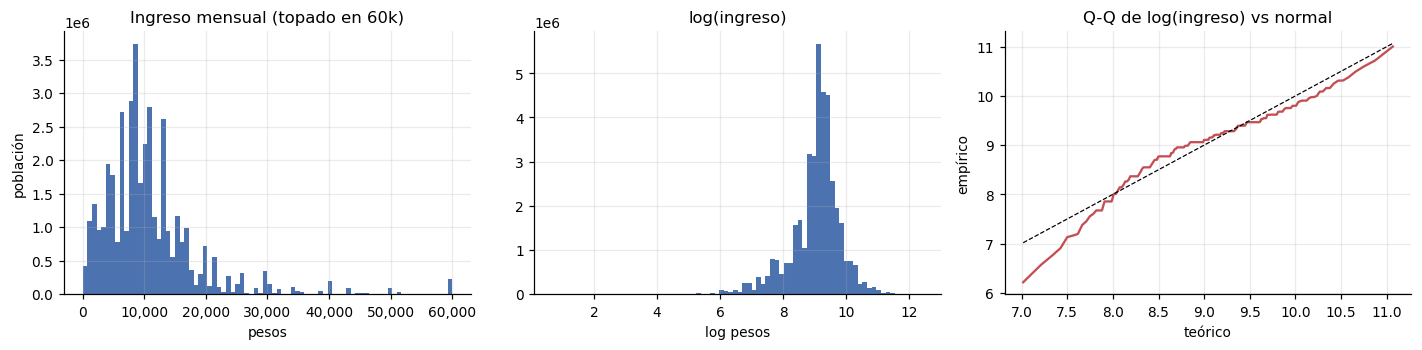

In [3]:
ing_ocu = ING_POS.where(OCU)
w_ocu   = W.where(OCU)

resumen = pd.DataFrame({
    "estadístico": ["n muestra", "población expandida", "media", "p10", "p25", "mediana",
                    "p75", "p90", "p95", "p99", "asimetría (log)"],
    "valor": [
        int(ing_ocu.notna().sum()),
        w_ocu.where(ing_ocu.notna(), 0).sum(),
        w_mean(ing_ocu),
        *[w_quantile(ing_ocu, q) for q in (.10, .25, .50, .75, .90, .95, .99)],
        float(np.log(ing_ocu.dropna()).skew()),
    ]})
resumen["valor"] = resumen["valor"].map(lambda v: f"{v:,.2f}")
display(resumen)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
x = ing_ocu.dropna()
wx = w_ocu[x.index]

ax[0].hist(x.clip(upper=60000), bins=80, weights=wx, color="#4C72B0")
ax[0].set_title("Ingreso mensual (topado en 60k)"); ax[0].xaxis.set_major_formatter(pesos())
ax[0].set_xlabel("pesos"); ax[0].set_ylabel("población")

ax[1].hist(np.log(x), bins=80, weights=wx, color="#4C72B0")
ax[1].set_title("log(ingreso)"); ax[1].set_xlabel("log pesos")

from scipy import stats as st
qs = np.linspace(.005, .995, 200)
emp = [w_quantile(np.log(x), q, wx) for q in qs]
teo = st.norm.ppf(qs, np.average(np.log(x), weights=wx), np.sqrt(w_var(np.log(x), wx)))
ax[2].plot(teo, emp, lw=1.5, color="#C44E52"); ax[2].plot(teo, teo, "k--", lw=.8)
ax[2].set_title("Q-Q de log(ingreso) vs normal")
ax[2].set_xlabel("teórico"); ax[2].set_ylabel("empírico")
plt.show()

,regla,% de la población ocupada con ingreso
0,múltiplo de 100,49.3
1,múltiplo de 500,26.4
2,"múltiplo de 1,000",24.0
3,"múltiplo de 5,000",8.7
4,los 15 valores más frecuentes,50.3


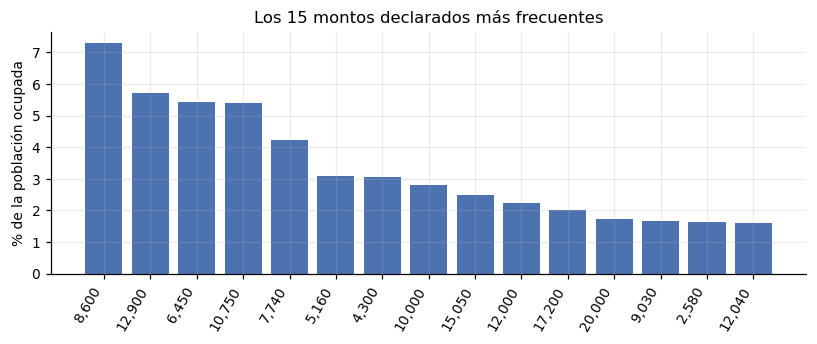

Lectura: si el % en múltiplos de 1,000 supera ~50%, `ingocup` no es una medición
continua. Consecuencias prácticas:
  · No persigas RMSE bajo — hay un piso de error impuesto por el redondeo del informante.
  · Un modelo de rangos (multiclase ordinal) puede ser más honesto que uno de punto.
  · Evalúa con métricas de banda: % dentro de ±20%, o dentro del rango correcto de SM.


In [4]:
# --- amontonamiento (heaping) en cifras redondas -----------------------------
top = (pd.DataFrame({"ing": x, "w": wx}).groupby("ing")["w"].sum()
         .sort_values(ascending=False).head(15))
top_pct = 100 * top / wx.sum()

heap = pd.DataFrame({
    "regla": ["múltiplo de 100", "múltiplo de 500", "múltiplo de 1,000",
              "múltiplo de 5,000", "los 15 valores más frecuentes"],
    "% de la población ocupada con ingreso": [
        100 * w_share(ing_ocu.mod(100).eq(0), ing_ocu.notna()),
        100 * w_share(ing_ocu.mod(500).eq(0), ing_ocu.notna()),
        100 * w_share(ing_ocu.mod(1000).eq(0), ing_ocu.notna()),
        100 * w_share(ing_ocu.mod(5000).eq(0), ing_ocu.notna()),
        float(top_pct.sum()),
    ]})
heap["% de la población ocupada con ingreso"] = heap.iloc[:, 1].round(1)
display(heap)

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar([f"{int(v):,}" for v in top.index], top_pct.values, color="#4C72B0")
ax.set_title("Los 15 montos declarados más frecuentes")
ax.set_ylabel("% de la población ocupada"); plt.xticks(rotation=60, ha="right")
plt.show()

print("Lectura: si el % en múltiplos de 1,000 supera ~50%, `ingocup` no es una medición\n"
      "continua. Consecuencias prácticas:\n"
      "  · No persigas RMSE bajo — hay un piso de error impuesto por el redondeo del informante.\n"
      "  · Un modelo de rangos (multiclase ordinal) puede ser más honesto que uno de punto.\n"
      "  · Evalúa con métricas de banda: % dentro de ±20%, o dentro del rango correcto de SM.")

## 2. Los ceros: la sección que cambia el proyecto

En el microdato de 2026 T1, la no respuesta de ingreso **no llega como `999998`**: llega como
`ingocup = 0`. Se ve directamente en la vista previa del notebook de unión — personas con
`clase2 = 1`, `pos_ocu = 1` y 42-48 horas trabajadas a la semana, con ingreso cero. Un asalariado
con jornada completa no gana cero.

Eso significa que `ingocup = 0` entre ocupados agrupa tres poblaciones que hay que separar:

1. **Trabajadores sin pago** (`pos_ocu = 4`) — el cero es verdadero, es el negocio familiar.
2. **No respuesta con rango** — no dieron monto pero sí contestaron `c2_p6c` (el rango en
   salarios mínimos). Información parcial recuperable.
3. **No respuesta total** — ni monto ni rango.

La distinción no es cosmética. Si entrenas sobre `ingocup > 0` estás haciendo *complete-case
analysis* sobre el 57-79% de la muestra, con la tasa de completitud variando por estado. Es el
mismo problema que ya trabajas del lado crediticio, y aquí sí tienes con qué medirlo.

In [5]:
# --- descomposición de los ocupados ------------------------------------------
tiene_monto  = OCU & (ING > 0)
sin_pago     = OCU & POS_OCU.eq(4) & (ING == 0)
p6c = df["c2_p6c"].astype("string").str.strip() if "c2_p6c" in df.columns else pd.Series(pd.NA, index=df.index)
tiene_rango  = p6c.notna() & p6c.ne("") & p6c.ne("0")
nr_con_rango = OCU & (ING == 0) & ~POS_OCU.eq(4) & tiene_rango
nr_total     = OCU & (ING == 0) & ~POS_OCU.eq(4) & ~tiene_rango

grupos = {
    "1. Declaró monto":                    tiene_monto,
    "2. Sin pago (pos_ocu = 4)":           sin_pago,
    "3. No respuesta, con rango p6c":      nr_con_rango,
    "4. No respuesta total":               nr_total,
}
desc = pd.DataFrame([{
    "grupo": k,
    "n_muestra": int(v.sum()),
    "poblacion": W.where(v, 0).sum(),
    "% de ocupados": 100 * W.where(v, 0).sum() / W.where(OCU, 0).sum(),
    "hrs medianas": w_quantile(num("hrsocup").where(v)),
} for k, v in grupos.items()])
desc["poblacion"] = desc["poblacion"].map("{:,.0f}".format)
desc["% de ocupados"] = desc["% de ocupados"].round(1)
desc["hrs medianas"] = desc["hrs medianas"].round(0)
display(desc)

cubierto = 100 * W.where(tiene_monto | sin_pago, 0).sum() / W.where(OCU, 0).sum()
recuperable = 100 * W.where(nr_con_rango, 0).sum() / W.where(OCU, 0).sum()
print(f"Información de ingreso utilizable tal cual: {cubierto:.1f}% de los ocupados")
print(f"Recuperable vía rango p6c:                 +{recuperable:.1f} puntos")
print(f"Irrecuperable:                              {100-cubierto-recuperable:.1f}%")

,grupo,n_muestra,poblacion,% de ocupados,hrs medianas
0,1. Declaró monto,126226,"40,166,074",67.1,43.0
1,2. Sin pago (pos_ocu = 4),5972,"2,008,939",3.4,29.0
2,"3. No respuesta, con rango p6c",54381,"16,916,457",28.2,44.0
3,4. No respuesta total,2025,"801,830",1.3,30.0


Información de ingreso utilizable tal cual: 70.4% de los ocupados
Recuperable vía rango p6c:                 +28.2 puntos
Irrecuperable:                              1.3%


In [6]:
# --- la no respuesta no es aleatoria: ¿con qué correlaciona? -----------------
elegible = OCU & ~POS_OCU.eq(4)          # universo donde el cero significa no respuesta
no_resp  = elegible & (ING == 0)

def tasa_nr(var, etiqueta, mapa=None):
    v = df[var].astype(str)
    filas = []
    for k in sorted(v[elegible].unique()):
        m = elegible & v.eq(k)
        if W.where(m, 0).sum() == 0:
            continue
        filas.append({etiqueta: mapa.get(k, k) if mapa else k,
                      "n": int(m.sum()),
                      "% no respuesta": 100 * w_share(no_resp, m)})
    return pd.DataFrame(filas).sort_values("% no respuesta", ascending=False)

MAPAS = {
    "pos_ocu":  {"1": "Subordinado remunerado", "2": "Empleador", "3": "Cuenta propia"},
    "emp_ppal": {"1": "Informal", "2": "Formal"},
    "t_loc_tri":{"1": "100k+ hab", "2": "15k-100k", "3": "2.5k-15k", "4": "<2.5k"},
    "seg_soc":  {"1": "Con acceso a salud", "2": "Sin acceso", "3": "No especificado"},
}
for v, et in [("pos_ocu", "Posición en la ocupación"), ("emp_ppal", "Formalidad"),
              ("t_loc_tri", "Tamaño de localidad"), ("seg_soc", "Acceso a salud")]:
    if v in df.columns:
        display(tasa_nr(v, et, MAPAS.get(v)))

,Posición en la ocupación,n,% no respuesta
1,Empleador,9672,38.985457
2,Cuenta propia,39673,34.178257
0,Subordinado remunerado,133287,28.802546


,Formalidad,n,% no respuesta
1,Formal,90554,36.948188
0,Informal,92078,25.095335


,Tamaño de localidad,n,% no respuesta
0,100k+ hab,107244,35.043621
1,15k-100k,24220,28.187070
2,2.5k-15k,23814,25.610838
3,<2.5k,27354,23.819347


,Acceso a salud,n,% no respuesta
2,No especificado,1311,79.782652
0,Con acceso a salud,79233,35.667581
1,Sin acceso,102088,26.665570


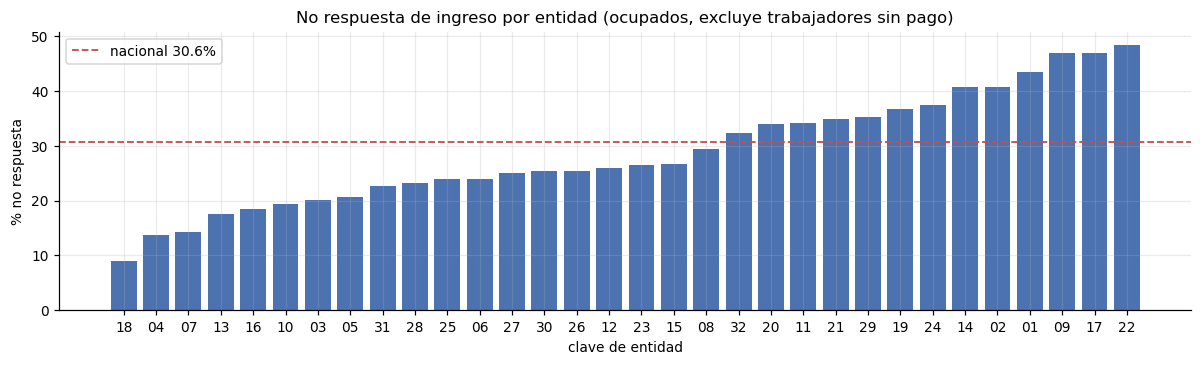

Rango entre entidades: 8.9% – 48.4% (razón 5.4x)

Esto es lo importante: la tasa de no respuesta VARÍA POR GEOGRAFÍA. Cualquier agregado
municipal calculado sobre casos completos se estima en cada municipio sobre una fracción
distinta de su población, y esa fracción está correlacionada con informalidad. El sesgo
no se promedia: se mete directo al feature geográfico que quieres usar.


In [7]:
# --- dispersión geográfica de la no respuesta --------------------------------
ent = df["cve_ent"].astype(str)
por_ent = pd.DataFrame([{
    "cve_ent": e,
    "n": int((elegible & ent.eq(e)).sum()),
    "nr_%": 100 * w_share(no_resp, elegible & ent.eq(e)),
} for e in sorted(ent.unique())]).sort_values("nr_%")

nac = 100 * w_share(no_resp, elegible)
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(por_ent["cve_ent"], por_ent["nr_%"], color="#4C72B0")
ax.axhline(nac, color="#C44E52", ls="--", lw=1.2, label=f"nacional {nac:.1f}%")
ax.set_title("No respuesta de ingreso por entidad (ocupados, excluye trabajadores sin pago)")
ax.set_ylabel("% no respuesta"); ax.set_xlabel("clave de entidad"); ax.legend()
plt.show()

print(f"Rango entre entidades: {por_ent['nr_%'].min():.1f}% – {por_ent['nr_%'].max():.1f}% "
      f"(razón {por_ent['nr_%'].max()/max(por_ent['nr_%'].min(),1e-9):.1f}x)")
print("\nEsto es lo importante: la tasa de no respuesta VARÍA POR GEOGRAFÍA. Cualquier agregado\n"
      "municipal calculado sobre casos completos se estima en cada municipio sobre una fracción\n"
      "distinta de su población, y esa fracción está correlacionada con informalidad. El sesgo\n"
      "no se promedia: se mete directo al feature geográfico que quieres usar.")

## 3. ¿MAR o MNAR? Aquí sí se puede contestar

Normalmente no se puede saber si la no respuesta depende del valor no observado — por definición
no lo observas. La ENOE tiene una salida: `c2_p6c` pregunta el ingreso **en múltiplos del salario
mínimo**, y buena parte de quienes no dan monto sí contestan el rango.

Eso convierte un problema MNAR en uno con información parcial observada, exactamente como el
*reject inference* con burós externos: no ves el desempeño, pero ves una señal correlacionada.

El test: comparar la distribución de `c2_p6c` entre quienes declararon monto y quienes no.
Si las distribuciones coinciden, la no respuesta es ignorable condicional a las covariables.
Si difieren, el complete-case está sesgado y sabes en qué dirección y cuánto.

Catálogo encontrado: conjunto_de_datos_enoe_2026_1t_csv/conjunto_de_datos_coe2_enoe_2026_1t/catalogos/p6c.csv


,0,1
0,CVE,DESCRIP
1,1,menor?
2,2,igual a esta cantidad?
3,3,mÃ¡s de 1 salario mÃ­nimo hasta 2?
4,4,mÃ¡s de 2 salarios mÃ­nimos hasta 3?
5,5,mÃ¡s de 3 salarios mÃ­nimos hasta 5?
6,6,mÃ¡s de 5 salarios mÃ­nimos hasta 10?
7,7,mÃ¡s de 10 salarios mÃ­nimos?
8,8,No quiso dar informaciÃ³n
9,9,No sabe



>>> VERIFICA que PUNTOS_SM corresponda a estas categorías antes de usar los números.


,p6c,SM (punto medio),% entre quienes declararon monto,% entre no respondientes
0,1,0.5,0.0,15.3
1,2,1.0,0.0,20.0
2,3,1.5,0.0,25.5
3,4,2.5,0.0,7.2
4,5,4.0,0.0,1.5
5,6,7.5,0.0,0.4
6,7,12.0,0.0,0.2


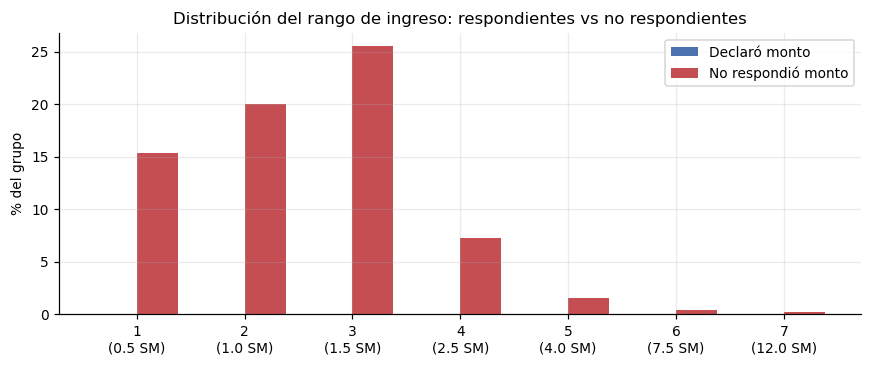

In [8]:
# --- catálogo de p6c: intenta leerlo del paquete original --------------------
PUNTOS_SM = {1: 0.5, 2: 1.0, 3: 1.5, 4: 2.5, 5: 4.0, 6: 7.5, 7: 12.0}   # puntos medios
cat_path = list(BASE.glob("*coe2*/catalogos/p6c.csv")) if BASE.exists() else []
if cat_path:
    print(f"Catálogo encontrado: {cat_path[0]}")
    display(pd.read_csv(cat_path[0], encoding="latin-1", header=None).head(15))
    print("\n>>> VERIFICA que PUNTOS_SM corresponda a estas categorías antes de usar los números.")
else:
    print("No encontré catalogos/p6c.csv — PUNTOS_SM usa los cortes estándar de la ENOE.\n"
          ">>> Confírmalos contra tu catálogo; los montos imputados dependen de ellos.")

p6c_n = pd.to_numeric(p6c, errors="coerce")
comp = []
for k in sorted(PUNTOS_SM):
    m = p6c_n.eq(k)
    comp.append({
        "p6c": k, "SM (punto medio)": PUNTOS_SM[k],
        "% entre quienes declararon monto": 100 * w_share(m, tiene_monto),
        "% entre no respondientes":         100 * w_share(m, nr_con_rango),
    })
comp = pd.DataFrame(comp).round(1)
display(comp)

fig, ax = plt.subplots(figsize=(8, 3.4))
ancho, pos = .38, np.arange(len(comp))
ax.bar(pos - ancho/2, comp["% entre quienes declararon monto"], ancho,
       label="Declaró monto", color="#4C72B0")
ax.bar(pos + ancho/2, comp["% entre no respondientes"], ancho,
       label="No respondió monto", color="#C44E52")
ax.set_xticks(pos); ax.set_xticklabels([f"{k}\n({PUNTOS_SM[k]} SM)" for k in comp["p6c"]])
ax.set_ylabel("% del grupo"); ax.legend()
ax.set_title("Distribución del rango de ingreso: respondientes vs no respondientes")
plt.show()

In [9]:
# --- cuantificar el sesgo del complete-case ---------------------------------
SAL = num("salario").where(lambda s: s > 0)
ing_imputado = p6c_n.map(PUNTOS_SM) * SAL          # monto implícito por el rango

# a) mediana observada (complete-case)  b) mediana con no respondientes imputados
serie_cc  = ING_POS.where(tiene_monto)
serie_aum = ING_POS.where(tiene_monto).fillna(ing_imputado.where(nr_con_rango))

comparacion = pd.DataFrame({
    "estimación": ["Complete-case (solo declararon monto)",
                   "Aumentada con rango p6c imputado"],
    "n":          [int(serie_cc.notna().sum()), int(serie_aum.notna().sum())],
    "media":      [w_mean(serie_cc), w_mean(serie_aum)],
    "mediana":    [w_quantile(serie_cc), w_quantile(serie_aum)],
    "p25":        [w_quantile(serie_cc, .25), w_quantile(serie_aum, .25)],
    "p75":        [w_quantile(serie_cc, .75), w_quantile(serie_aum, .75)],
})
for c in ["media", "mediana", "p25", "p75"]:
    comparacion[c] = comparacion[c].round(0)
display(comparacion)

d_med = 100 * (comparacion.loc[1, "mediana"] / comparacion.loc[0, "mediana"] - 1)
print(f"Sesgo de la mediana nacional por usar solo casos completos: {d_med:+.1f}%")
print("\nOjo con la interpretación: la imputación por punto medio del rango es cruda y aplasta\n"
      "la varianza dentro de cada rango. Sirve para medir la DIRECCIÓN y el ORDEN DE MAGNITUD\n"
      "del sesgo, no como dato final. Para producción, imputación múltiple dentro del rango.")

,estimación,n,media,mediana,p25,p75
0,Complete-case (solo declararon monto),126226,11009.0,9030.0,6450.0,12900.0
1,Aumentada con rango p6c imputado,162533,11556.0,9582.0,6450.0,14373.0


Sesgo de la mediana nacional por usar solo casos completos: +6.1%

Ojo con la interpretación: la imputación por punto medio del rango es cruda y aplasta
la varianza dentro de cada rango. Sirve para medir la DIRECCIÓN y el ORDEN DE MAGNITUD
del sesgo, no como dato final. Para producción, imputación múltiple dentro del rango.


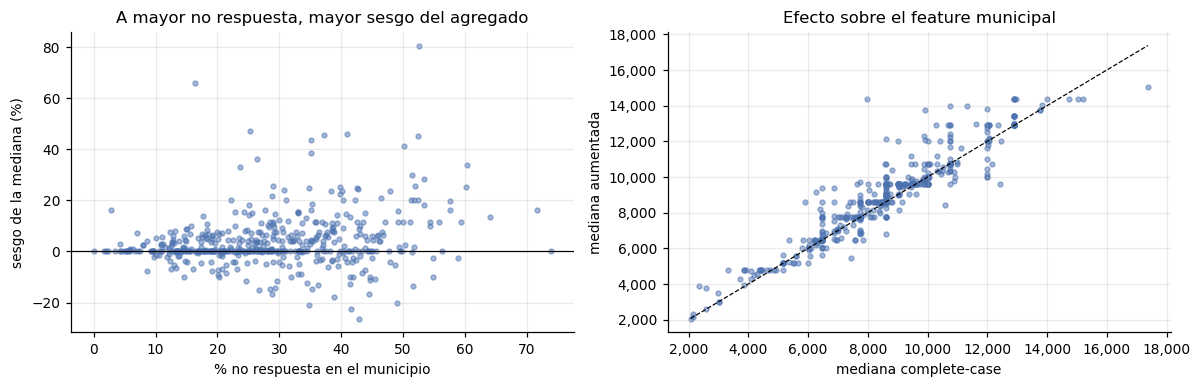

Municipios analizados (n≥50): 489
Correlación entre tasa de no respuesta y sesgo del agregado: +0.227
Sesgo mediano +0.7%, rango [-9.9%, +23.2%]

Si la correlación es positiva y marcada, el feature municipal que ya construiste
está sesgado de forma NO uniforme: subestima más donde hay más informalidad.


In [10]:
# --- el sesgo a nivel municipal: dónde muerde de verdad ----------------------
geo = df["cvegeo"].astype(str)
trab = pd.DataFrame({"cvegeo": geo, "w": W, "no_resp": no_resp,
                     "cc": serie_cc, "aum": serie_aum}).loc[elegible]

MIN_N = 50
filas = []
for g, x in trab.groupby("cvegeo", observed=True):
    if len(x) < MIN_N:
        continue
    filas.append({
        "cvegeo": g, "n": len(x),
        "nr_%": 100 * x["w"].where(x["no_resp"], 0).sum() / x["w"].sum(),
        "mediana_cc":  w_quantile(x["cc"],  .5, x["w"]),
        "mediana_aum": w_quantile(x["aum"], .5, x["w"]),
    })
mun = pd.DataFrame(filas)

if len(mun) < 10:
    print(f"Solo {len(mun)} municipios con n≥{MIN_N}: muestra insuficiente para este corte.")
else:
    mun = mun.dropna(subset=["mediana_cc", "mediana_aum"])
    mun = mun[mun["mediana_cc"] > 0]
    mun["sesgo_%"] = 100 * (mun["mediana_aum"] / mun["mediana_cc"] - 1)

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    ax[0].scatter(mun["nr_%"], mun["sesgo_%"], s=10, alpha=.5, color="#4C72B0")
    ax[0].axhline(0, color="k", lw=.8)
    ax[0].set_xlabel("% no respuesta en el municipio")
    ax[0].set_ylabel("sesgo de la mediana (%)")
    ax[0].set_title("A mayor no respuesta, mayor sesgo del agregado")

    lims = [mun[["mediana_cc", "mediana_aum"]].min().min(),
            mun[["mediana_cc", "mediana_aum"]].max().max()]
    ax[1].scatter(mun["mediana_cc"], mun["mediana_aum"], s=10, alpha=.5, color="#4C72B0")
    ax[1].plot(lims, lims, "k--", lw=.8)
    ax[1].set_xlabel("mediana complete-case"); ax[1].set_ylabel("mediana aumentada")
    ax[1].set_title("Efecto sobre el feature municipal")
    ax[1].xaxis.set_major_formatter(pesos()); ax[1].yaxis.set_major_formatter(pesos())
    plt.show()

    r = np.corrcoef(mun["nr_%"], mun["sesgo_%"])[0, 1]
    print(f"Municipios analizados (n≥{MIN_N}): {len(mun)}")
    print(f"Correlación entre tasa de no respuesta y sesgo del agregado: {r:+.3f}")
    print(f"Sesgo mediano {mun['sesgo_%'].median():+.1f}%, "
          f"rango [{mun['sesgo_%'].quantile(.05):+.1f}%, {mun['sesgo_%'].quantile(.95):+.1f}%]")
    print("\nSi la correlación es positiva y marcada, el feature municipal que ya construiste\n"
          "está sesgado de forma NO uniforme: subestima más donde hay más informalidad.")

## 4. ¿Cuánta señal aporta cada bloque de variables?

La ENOE tiene 523 columnas, pero un modelo que puntúa a un solicitante **solo puede usar lo que
se sabe de ese solicitante**. La pregunta operativa no es "qué predice el ingreso en la ENOE",
sino "qué predice el ingreso usando únicamente variables que existen en un expediente".

Cuatro bloques, en orden de disponibilidad real:

- **T1 — Identidad y domicilio.** Edad, sexo, entidad, tamaño de localidad. Está en cualquier
  solicitud.
- **T2 — Agregados geográficos.** Derivables del domicilio vía `cvegeo`. Es exactamente el
  enriquecimiento que ya haces con el Rezago Social del CONEVAL.
- **T3 — Declarado en solicitud.** Escolaridad, estado conyugal, dependientes. Disponible si lo
  capturas, con la advertencia de que el solicitante tiene incentivo a inflarlo.
- **T4 — Laboral.** Posición en la ocupación, formalidad, rama, horas. **No lo tienes** para un
  no-hit. Se incluye para medir el costo de no tenerlo.

La brecha entre T3 y T4 es el precio de no conocer la situación laboral. La brecha T1→T2 es lo
que compra el enriquecimiento geográfico.

In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error

TIERS = {
    "T1 identidad + domicilio": ["eda", "sex", "cve_ent", "t_loc_tri"],
    "T2 + agregados geo":       ["mun_ing_mediana_shrunk", "ent_ing_mediana_ocup",
                                 "mun_tasa_informalidad", "mun_n_muestra", "ent_esc_media"],
    "T3 + declarado":           ["anios_esc", "niv_ins", "e_con", "n_hij"],
    "T4 + laboral (no disponible en no-hit)":
                                ["pos_ocu", "emp_ppal", "seg_soc", "rama_est2",
                                 "scian", "tue_ppal", "hrsocup"],
}

modelo = OCU & (ING > 0) & EDAD.between(15, 80)
d = df.loc[modelo].copy()
y = np.log(pd.to_numeric(d["ingocup"], errors="coerce"))
sw = pd.to_numeric(d[FAC], errors="coerce")
# agrupar por UPM: personas de la misma unidad de muestreo no deben cruzar train/test
grupos = d["upm"].astype(str) if "upm" in d.columns else d["cvegeo"].astype(str)
print(f"Muestra de modelado: {len(d):,} ocupados con ingreso declarado, "
      f"{grupos.nunique():,} UPM distintas")

def preparar(cols):
    X = pd.DataFrame(index=d.index)
    for c in cols:
        if c not in d.columns:
            continue
        s = pd.to_numeric(d[c], errors="coerce")
        X[c] = s if s.notna().mean() > .5 else d[c].astype("category").cat.codes
    return X

acumulado, resultados = [], []
for nombre, cols in TIERS.items():
    acumulado += cols
    X = preparar(acumulado)
    if X.empty:
        continue
    oof = pd.Series(np.nan, index=d.index)
    for tr, te in GroupKFold(n_splits=4).split(X, y, groups=grupos):
        m = HistGradientBoostingRegressor(max_iter=250, learning_rate=.08,
                                          max_depth=6, random_state=0)
        m.fit(X.iloc[tr], y.iloc[tr], sample_weight=sw.iloc[tr])
        oof.iloc[te] = m.predict(X.iloc[te])
    resultados.append({
        "bloque": nombre, "n_features": X.shape[1],
        "R2_log": r2_score(y, oof, sample_weight=sw),
        "MAE_log": mean_absolute_error(y, oof, sample_weight=sw),
        "MAE_pesos": float(np.average(np.abs(np.exp(oof) - np.exp(y)), weights=sw)),
        "% dentro de ±20%": 100 * float(np.average(
            (np.abs(np.exp(oof) / np.exp(y) - 1) <= .20).astype(float), weights=sw)),
    })

res = pd.DataFrame(resultados)
res["Δ R2"] = res["R2_log"].diff().fillna(res["R2_log"])
display(res.round(4))

Muestra de modelado: 125,389 ocupados con ingreso declarado, 20,090 UPM distintas


,bloque,n_features,R2_log,MAE_log,MAE_pesos,% dentro de ±20%,Δ R2
0,T1 identidad + domicilio,4,0.2402,0.4875,4733.1172,31.6748,0.2402
1,T2 + agregados geo,9,0.2750,0.4731,4619.7009,33.1705,0.0348
2,T3 + declarado,13,0.3537,0.4471,4338.7897,33.9705,0.0787
3,T4 + laboral (no disponible en no-hit),20,0.5780,0.3537,3696.1389,42.2055,0.2242


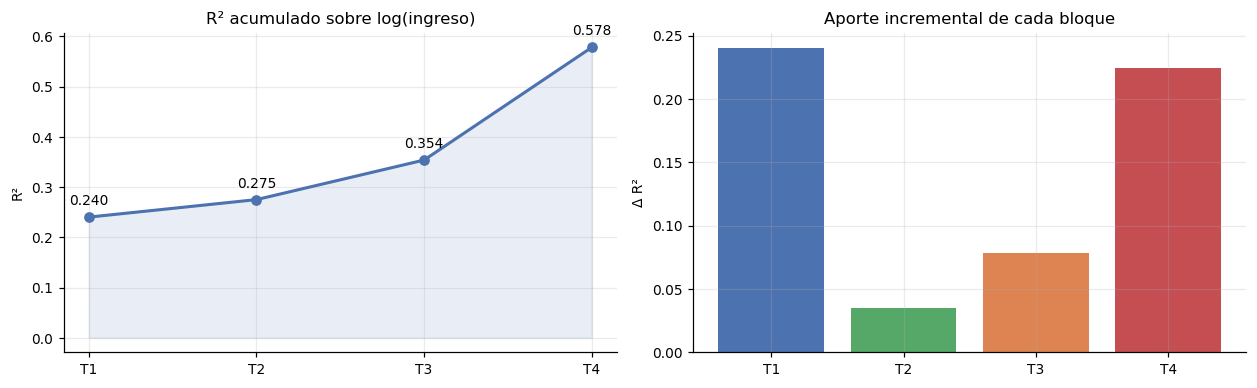

Techo con variables disponibles para un no-hit (T1+T2+T3): 0.354
Techo si conocieras la situación laboral (T1..T4):          0.578
Costo de no observar lo laboral: 0.224 de R²

Cómo leerlo: un R² de 0.2-0.3 sobre log-ingreso es bajo en abstracto, pero es lo normal
en estimación de ingresos con covariables demográficas. La conclusión útil no es el
número sino la FORMA de la curva: si T2 aporta poco sobre T1, el enriquecimiento
geográfico no está comprando lo que cuesta mantenerlo.


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
etiquetas = [b.split(" ")[0] for b in res["bloque"]]

ax[0].plot(etiquetas, res["R2_log"], "o-", color="#4C72B0", lw=2)
ax[0].fill_between(etiquetas, 0, res["R2_log"], alpha=.12, color="#4C72B0")
ax[0].set_title("R² acumulado sobre log(ingreso)"); ax[0].set_ylabel("R²")
for i, v in enumerate(res["R2_log"]):
    ax[0].annotate(f"{v:.3f}", (i, v), textcoords="offset points", xytext=(0, 8), ha="center")

ax[1].bar(etiquetas, res["Δ R2"], color=["#4C72B0", "#55A868", "#DD8452", "#C44E52"])
ax[1].set_title("Aporte incremental de cada bloque"); ax[1].set_ylabel("Δ R²")
plt.show()

r2_disp = res.loc[res.bloque.str.startswith("T3"), "R2_log"].iloc[0] if len(res) > 2 else np.nan
r2_full = res["R2_log"].iloc[-1]
print(f"Techo con variables disponibles para un no-hit (T1+T2+T3): {r2_disp:.3f}")
print(f"Techo si conocieras la situación laboral (T1..T4):          {r2_full:.3f}")
print(f"Costo de no observar lo laboral: {r2_full - r2_disp:.3f} de R²\n")
print("Cómo leerlo: un R² de 0.2-0.3 sobre log-ingreso es bajo en abstracto, pero es lo normal\n"
      "en estimación de ingresos con covariables demográficas. La conclusión útil no es el\n"
      "número sino la FORMA de la curva: si T2 aporta poco sobre T1, el enriquecimiento\n"
      "geográfico no está comprando lo que cuesta mantenerlo.")

## 5. ¿Cuánto explica de verdad la geografía?

El enriquecimiento geográfico descansa en un supuesto implícito: que saber el municipio dice
mucho sobre el ingreso. Se puede medir directo con la correlación intraclase — qué fracción de
la varianza de log-ingreso está *entre* municipios y no *dentro* de cada municipio.

Un ICC bajo no invalida el feature, pero sí acota lo que puede aportar. Y hay un segundo límite,
más duro: la ENOE solo toca **1,038 municipios de los ~2,475 del país**. Para el resto no hay
agregado que pegar.

In [ ]:
log_ing = np.log(ING_POS.where(modelo))
val = log_ing.notna() & W.notna()

def icc(nivel, mask=None):
    m = val if mask is None else mask
    g = df.loc[m, nivel].astype(str)
    yy, ww = log_ing[m], W[m]
    mu = np.average(yy, weights=ww)
    entre = 0.0
    for k, idx in yy.groupby(g).groups.items():
        wk = ww[idx].sum()
        entre += wk * (np.average(yy[idx], weights=ww[idx]) - mu) ** 2
    entre /= ww.sum()
    total = np.average((yy - mu) ** 2, weights=ww)
    return entre / total

niveles = [("cve_ent", "Entidad"), ("cvegeo", "Municipio"),
           ("t_loc_tri", "Tamaño de localidad"), ("cd_a", "Ciudad autorrepresentada")]
tab = pd.DataFrame([{"nivel": et, "grupos": df.loc[val, n].nunique(),
                     "ICC (varianza explicada)": icc(n)}
                    for n, et in niveles if n in df.columns])

# El ICC crudo se infla cuando hay grupos con pocas observaciones: la media de cada grupo
# se estima con ruido y ese ruido se cuenta como "varianza entre grupios". Se recalcula
# restringiendo a municipios con muestra suficiente.
tam = df.loc[val, "cvegeo"].astype(str).value_counts()
grandes = set(tam[tam >= 100].index)
if len(grandes) >= 10:
    sub = val & df["cvegeo"].astype(str).isin(grandes)
    icc_g = icc("cvegeo", sub)
    tab.loc[len(tab)] = ["Municipio (solo n≥100)", len(grandes), icc_g]
tab["ICC (varianza explicada)"] = tab["ICC (varianza explicada)"].round(4)
display(tab)
print("El ICC municipal crudo está sesgado al alza cuando muchos municipios tienen pocos\n"
      "casos. La fila restringida a n≥100 es la lectura confiable.\n")

MUNICIPIOS_MX = 2475
cubiertos = df["cvegeo"].astype(str).nunique()
pct = 100 * cubiertos / MUNICIPIOS_MX
print(f"Municipios con datos ENOE: {cubiertos:,} de ~{MUNICIPIOS_MX:,} ({pct:.0f}%)")
if pct < 90:
    print(f"El {100-pct:.0f}% restante son mayoritariamente rurales y pequeños. Si tu cartera\n"
          "tiene solicitantes ahí, el feature municipal llega nulo justo en el segmento con\n"
          "menor bancarización — y la imputación de reserva (media estatal) borra precisamente\n"
          "la variación que buscabas capturar.")

In [ ]:
# --- ¿el agregado municipal predice al individuo? ----------------------------
d2 = df.loc[modelo].copy()
d2["log_ing"] = np.log(pd.to_numeric(d2["ingocup"], errors="coerce"))
d2["med_mun"] = pd.to_numeric(d2.get("mun_ing_mediana_shrunk"), errors="coerce")
ok = d2[["log_ing", "med_mun", FAC]].dropna()

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
ax[0].scatter(ok["med_mun"], np.exp(ok["log_ing"]).clip(upper=60000),
              s=3, alpha=.05, color="#4C72B0")
ax[0].set_xlabel("mediana municipal (feature)"); ax[0].set_ylabel("ingreso individual")
ax[0].set_title("Dispersión individual dentro de cada municipio")
ax[0].xaxis.set_major_formatter(pesos()); ax[0].yaxis.set_major_formatter(pesos())

deciles = pd.qcut(ok["med_mun"], 10, duplicates="drop", labels=False)
p = ok.groupby(deciles).apply(
    lambda x: pd.Series({
        "p25": np.exp(np.percentile(x.log_ing, 25)),
        "p50": np.exp(np.percentile(x.log_ing, 50)),
        "p75": np.exp(np.percentile(x.log_ing, 75))}), include_groups=False)
ax[1].fill_between(p.index, p["p25"], p["p75"], alpha=.25, color="#4C72B0", label="P25-P75")
ax[1].plot(p.index, p["p50"], "o-", color="#C44E52", label="mediana")
ax[1].set_xlabel("decil del feature municipal"); ax[1].set_ylabel("ingreso individual")
ax[1].set_title("Señal vs ruido del feature geográfico")
ax[1].yaxis.set_major_formatter(pesos()); ax[1].legend()
plt.show()

r_pears = np.corrcoef(ok["log_ing"], np.log(ok["med_mun"]))[0, 1]
print(f"Correlación log-ingreso individual vs log-mediana municipal: {r_pears:.3f} "
      f"(R² implícito {r_pears**2:.3f})")
print("El ancho de la banda P25-P75 dentro de cada decil es el punto: el feature mueve el\n"
      "centro de la distribución, pero la dispersión individual dentro de un mismo municipio\n"
      "es mucho mayor que la diferencia entre municipios.")

## 6. El segmento informal como proxy de tu población no-hit

Nadie es "no-hit" en la ENOE, pero la informalidad es el proxy más cercano: sin acceso a
instituciones de salud por el empleo, sin prestaciones, sin contrato. Es la población que
históricamente no genera expediente crediticio.

Dos cosas a medir, y la segunda importa más que la primera:

1. **Nivel** — cuánto menor es el ingreso informal (esperado y conocido).
2. **Dispersión** — cuánto más variable. Si la varianza condicional es mayor, un modelo entrenado
   mayoritariamente sobre población formal produce intervalos de predicción demasiado angostos
   al extrapolar al segmento informal. El error no está en el punto estimado sino en la
   confianza que le asignas.

In [ ]:
formal   = OCU & num("emp_ppal").eq(2) & (ING > 0)
informal = OCU & num("emp_ppal").eq(1) & (ING > 0)

def perfil(m, nombre):
    li = np.log(ING_POS.where(m))
    return {
        "segmento": nombre, "n": int(m.sum()),
        "población": W.where(m, 0).sum(),
        "mediana": w_quantile(ING_POS.where(m)),
        "media": w_mean(ING_POS.where(m)),
        "p10": w_quantile(ING_POS.where(m), .10),
        "p90": w_quantile(ING_POS.where(m), .90),
        "desv. est. de log": np.sqrt(w_var(li)),
        "escolaridad media": w_mean(num("anios_esc").where(m).where(lambda s: s < 99)),
        "horas medianas": w_quantile(num("hrsocup").where(m)),
    }
comp2 = pd.DataFrame([perfil(formal, "Formal"), perfil(informal, "Informal")])
comp2["población"] = comp2["población"].map("{:,.0f}".format)
for c in ["mediana", "media", "p10", "p90", "horas medianas"]:
    comp2[c] = comp2[c].round(0)
for c in ["desv. est. de log", "escolaridad media"]:
    comp2[c] = comp2[c].round(2)
display(comp2)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
for m, nom, col in [(formal, "Formal", "#4C72B0"), (informal, "Informal", "#C44E52")]:
    xx = np.log(ING_POS.where(m)).dropna()
    ax[0].hist(xx, bins=70, weights=W[xx.index], density=True, alpha=.5, label=nom, color=col)
ax[0].set_xlabel("log(ingreso)"); ax[0].set_ylabel("densidad"); ax[0].legend()
ax[0].set_title("Distribución del ingreso por formalidad")

# dispersión condicional por escolaridad
esc = num("anios_esc").where(lambda s: s < 99)
banda = pd.cut(esc, [-1, 6, 9, 12, 16, 30], labels=["≤6", "7-9", "10-12", "13-16", "17+"])
filas = []
for b in banda.cat.categories:
    for m, nom in [(formal, "Formal"), (informal, "Informal")]:
        sel = m & banda.eq(b)
        if sel.sum() > 30:
            filas.append({"escolaridad": b, "segmento": nom,
                          "sd_log": np.sqrt(w_var(np.log(ING_POS.where(sel))))})
disp = pd.DataFrame(filas).pivot(index="escolaridad", columns="segmento", values="sd_log")
disp.plot(kind="bar", ax=ax[1], color=["#4C72B0", "#C44E52"], rot=0)
ax[1].set_title("Dispersión condicional (desv. est. de log-ingreso)")
ax[1].set_ylabel("sd de log"); ax[1].set_xlabel("años de escolaridad")
plt.show()
display(disp.round(3))

In [ ]:
# --- lo que esto implica para un modelo entrenado en población bancarizada ---
sd_f = np.sqrt(w_var(np.log(ING_POS.where(formal))))
sd_i = np.sqrt(w_var(np.log(ING_POS.where(informal))))
med_f, med_i = w_quantile(ING_POS.where(formal)), w_quantile(ING_POS.where(informal))
nr_f = 100 * w_share(no_resp, elegible & num("emp_ppal").eq(2))
nr_i = 100 * w_share(no_resp, elegible & num("emp_ppal").eq(1))

print(f"Mediana informal / formal:              {med_i/med_f:.2f}x")
print(f"Dispersión (sd log) informal / formal:  {sd_i/sd_f:.2f}x")
print(f"No respuesta de ingreso — formal {nr_f:.1f}%  vs  informal {nr_i:.1f}%\n")
print("Las tres cifras apuntan al mismo lugar y se acumulan:")
print("  1. El segmento no-hit gana menos → desplazamiento de nivel, corregible con un intercepto.")
print("  2. Gana con más dispersión → tus intervalos de predicción se quedan cortos justo ahí.")
print("  3. Responde menos → está subrepresentado incluso DENTRO de la ENOE.")
print("\nEl tercero es el que muerde: la fuente auxiliar que usarías para corregir el sesgo de\n"
      "selección crediticia tiene su propio sesgo de selección, en la misma dirección.")

## 7. Tablas de calibración

Entregable operativo: cuantiles de ingreso por celdas construidas solo con variables que existen
en un expediente. Sirven como *prior*, como referencia de calibración o como offset en un modelo
de dos muestras.

Cada celda lleva su `n` y una versión encogida hacia el margen estatal, para que las celdas
chicas no metan ruido. Se calculan sobre la serie aumentada con `p6c`, no sobre casos completos.

In [ ]:
grupo_edad = pd.cut(EDAD, [14, 24, 34, 44, 54, 64, 100],
                    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"])
niv = df["niv_ins"].astype(str) if "niv_ins" in df.columns else pd.Series("NA", index=df.index)

base_cal = OCU & serie_aum.notna() & EDAD.between(18, 80)
celdas = pd.DataFrame({
    "cve_ent": df["cve_ent"].astype(str), "t_loc_tri": df["t_loc_tri"].astype(str),
    "grupo_edad": grupo_edad.astype(str), "sex": df["sex"].astype(str), "niv_ins": niv,
    "ing": serie_aum, "w": W,
})[base_cal]

llaves = ["cve_ent", "t_loc_tri", "grupo_edad", "sex", "niv_ins"]
filas = []
for k, g in celdas.groupby(llaves, observed=True):
    filas.append({**dict(zip(llaves, k)), "n": len(g),
                  "p25": w_quantile(g["ing"], .25, g["w"]),
                  "p50": w_quantile(g["ing"], .50, g["w"]),
                  "p75": w_quantile(g["ing"], .75, g["w"])})
cal = pd.DataFrame(filas)

# encogimiento hacia el margen estatal
marg = celdas.groupby("cve_ent").apply(
    lambda g: w_quantile(g["ing"], .50, g["w"]), include_groups=False).rename("p50_ent")
cal = cal.merge(marg, on="cve_ent", how="left")
lam = cal["n"] / (cal["n"] + 40)
cal["p50_shrunk"] = (lam * cal["p50"] + (1 - lam) * cal["p50_ent"]).round(0)

print(f"{len(cal):,} celdas · mediana de n por celda: {cal['n'].median():.0f} · "
      f"celdas con n<20: {(cal['n']<20).mean()*100:.0f}%")
display(cal.sort_values("n", ascending=False).head(12).round(0))

# --- versión gruesa: menos resolución, mucho menos ruido ---------------------
llaves_g = ["cve_ent", "grupo_edad", "sex"]
filas_g = []
for k, g in celdas.groupby(llaves_g, observed=True):
    filas_g.append({**dict(zip(llaves_g, k)), "n": len(g),
                    "p25": w_quantile(g["ing"], .25, g["w"]),
                    "p50": w_quantile(g["ing"], .50, g["w"]),
                    "p75": w_quantile(g["ing"], .75, g["w"])})
cal_g = pd.DataFrame(filas_g)
print(f"\nVersión gruesa: {len(cal_g):,} celdas · mediana de n: {cal_g['n'].median():.0f} · "
      f"celdas con n<20: {(cal_g['n']<20).mean()*100:.0f}%")
display(cal_g.sort_values("n", ascending=False).head(8).round(0))

print("\nCuál usar: si la tabla fina tiene la mayoría de celdas por debajo de n=30, sus\n"
      "cuantiles son ruido y conviene la gruesa. La columna p50_shrunk de la fina ya mitiga\n"
      "esto, pero encoger mucho equivale a usar la gruesa con pasos extra.")

cal.to_csv(OUT / "tabla_calibracion_ingreso.csv", index=False)
cal_g.to_csv(OUT / "tabla_calibracion_ingreso_gruesa.csv", index=False)
if len(mun): mun.to_csv(OUT / "sesgo_no_respuesta_municipal.csv", index=False)
res.to_csv(OUT / "valor_incremental_features.csv", index=False)
print(f"\nExportado a {OUT}/")

## 8. Conclusiones y qué haría a continuación

### Lo que hay que arreglar antes de modelar

**No entrenes sobre `ingocup > 0`.** Ese filtro descarta entre 20% y 40% de los ocupados según el
estado, y descarta selectivamente a informales y trabajadores por cuenta propia — el corazón de
tu población objetivo. Usa la serie aumentada con `p6c`, y para producción imputación múltiple
dentro del rango en vez del punto medio.

**Separa `pos_ocu = 4` del resto.** Los trabajadores sin pago tienen ingreso laboral cero de
verdad. Mezclarlos con la no respuesta contamina tanto el numerador como el denominador.

**Revisa `ingocup_sm`.** El notebook de unión la calculó incluyendo los ceros, así que la mediana
en salarios mínimos que salió (0.45-1.12) está aplastada hacia abajo. Recalcúlala sobre
`ingocup > 0`.

### Sobre el enriquecimiento geográfico

La sección 5 da el veredicto en un número: el ICC municipal. Si sale en el rango típico de
0.05-0.15, el municipio mueve el centro de la distribución pero explica poco de la variación
individual. Eso no lo descarta — un feature que aporta 0.02 de R² puede valer la pena si es
barato — pero sí acota la expectativa, y hay que contrastarlo contra el costo de mantener el
pipeline y contra el hecho de que solo cubre 42% de los municipios del país.

Recomendación concreta: en vez de pegar la mediana municipal cruda, pega el **residual** respecto
a la predicción estatal × tamaño de localidad. Así el feature aporta solo lo que la geografía fina
añade sobre la gruesa, que es lo único que justifica su costo.

### Sobre la conexión con tu trabajo de sesgo de selección

La sección 6 deja ver algo incómodo: la ENOE, que querías usar como fuente auxiliar para corregir
el sesgo de selección de la población bancarizada, **tiene su propio sesgo de selección en la
misma dirección**. Los informales responden menos la pregunta de ingreso. Si aplicas IPW usando
pesos derivados de la ENOE sin corregir la no respuesta de ítem, arrastras el sesgo en lugar de
corregirlo.

La ruta limpia es tratarlo como dos etapas de selección: primero corriges no respuesta dentro de
la ENOE usando `p6c` como información parcial, y con la ENOE ya corregida construyes la
distribución de referencia contra la cual reponderas tu población de solicitantes. Es la misma
estructura de Heckman en dos pasos que ya trabajaste, aplicada un nivel más arriba.

### Siguiente paso natural

Enlazar 2026 T1 con 2026 T2 —que ya tienes en Drive— por el panel rotatorio. Con dos trimestres
puedes medir **volatilidad del ingreso a nivel persona**, que para riesgo de crédito importa más
que el nivel: dos solicitantes con el mismo ingreso medio y distinta varianza no son el mismo
riesgo. La ENOE es de las pocas fuentes en México que permite estimar eso por segmento.